# Phase 3: Box Least Squares (BLS) Candidate Detection

In Phase 1, we cleaned the light curve.
In Phase 2, we explored the stellar metadata (TIC).
Now, in Phase 3, we mathematically search the clean light curve for periodic planetary dips using **Box Least Squares (BLS)**.

This satisfies the core Hackathon requirement to extract physical parameters (Transit Depth, Orbital Period, Duration) *before* the AI classifies the dip.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import preprocessing as pp
from bls_detector import detect_transit_bls

plt.style.use('seaborn-v0_8-darkgrid')

C:\projects\EvoNex\venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 1. Data Ingestion & Preprocessing
We fetch the same WASP-126 light curve from Phase 1 and run it through our mathematical cleaner.

In [2]:
print("Fetching WASP-126...")
lc = lk.search_lightcurve("TIC 25155310", sector=1, author="SPOC").download()
clean_data = pp.process_lightcurve(lc)
t = clean_data['time']
f = clean_data['flux']

Fetching WASP-126...


## 2. Running BLS
We ask the BLS algorithm to test 10,000 different orbital periods to see which one mathematically fits the data perfectly.

In [3]:
best_params, periodogram = detect_transit_bls(t, f, min_period=1.5, max_period=10.0)

print("--- HACKATHON REQUIREMENTS EXTRACTED ---")
print(f"Orbital Period   : {best_params['period_days']:.4f} Days")
print(f"Transit Depth    : {best_params['transit_depth_ppm']:.0f} PPM")
print(f"Transit Duration : {best_params['duration_hours']:.2f} Hours")
print(f"Signal-to-Noise  : {best_params['bls_snr']:.2f}")

--- HACKATHON REQUIREMENTS EXTRACTED ---
Orbital Period   : 3.2877 Days
Transit Depth    : 1595 PPM
Transit Duration : 0.74 Hours
Signal-to-Noise  : 16.35


## 3. The Periodogram
This plot shows the "Power" of every period tested. The massive spike is the exact orbital period of the planet.

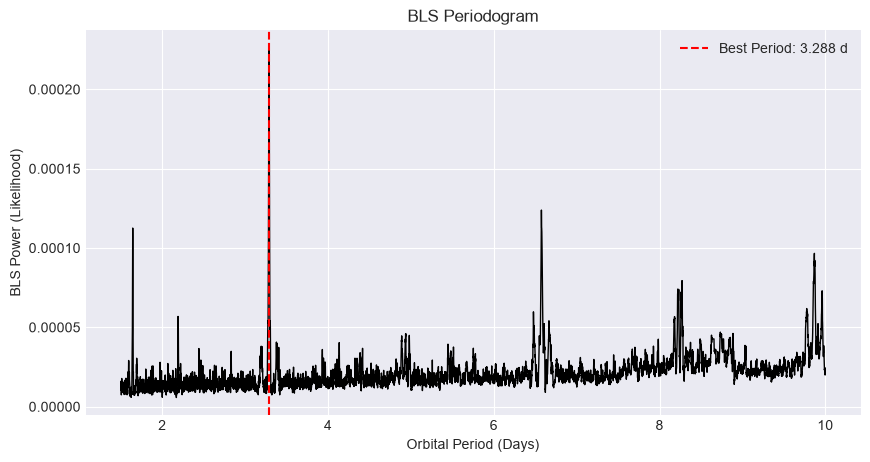

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(periodogram.period, periodogram.power, color='black', lw=1)
plt.axvline(best_params['period_days'], color='red', linestyle='--', label=f"Best Period: {best_params['period_days']:.3f} d")
plt.title("BLS Periodogram")
plt.xlabel("Orbital Period (Days)")
plt.ylabel("BLS Power (Likelihood)")
plt.legend()
plt.show()

## 4. Phase-Folding on the Detected Period
Now that the algorithm extracted the period and the exact transit epoch, we can fold the timeline and "zoom in" to prove we found the dip. 
**This specific shape is what the PyTorch model will eventually look at!**

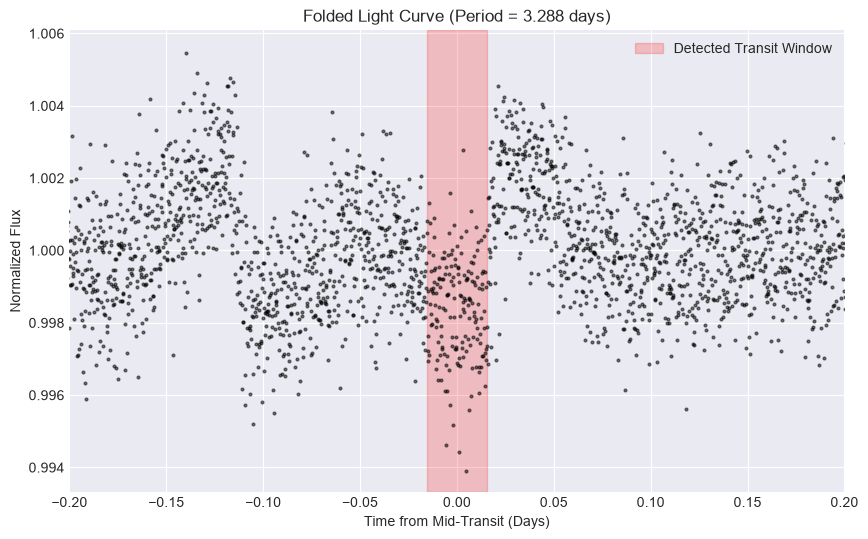

In [5]:
p = best_params['period_days']
t0 = best_params['transit_epoch']

# Calculate phase centered around 0
phase = ((t - t0 + 0.5 * p) % p) - 0.5 * p

plt.figure(figsize=(10, 6))
plt.plot(phase, f, '.', markersize=4, color='black', alpha=0.5)
plt.axvspan(-best_params['duration_hours']/24.0 / 2, best_params['duration_hours']/24.0 / 2, 
            color='red', alpha=0.2, label='Detected Transit Window')

plt.title(f"Folded Light Curve (Period = {p:.3f} days)")
plt.xlabel("Time from Mid-Transit (Days)")
plt.ylabel("Normalized Flux")
plt.xlim(-0.2, 0.2)
plt.legend()
plt.show()